In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import seaborn as sns

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, Predictive
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.metrics import mean_squared_error

from utils import Reservoir, DataGenerator, zoomed_plots

import warnings
warnings.filterwarnings("ignore")

/Users/giacomogasparotto/POD/Bayesian-Inference-in-High-Dimensional-Reservoir-Dynamics-for-Neural-Time-Series/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===========================================================
# GLOBAL PLOT STYLE 
# Note: Requires a working LaTeX installation on your system 
# (not in this specific case, the first three lines are commented)
# ===========================================================

plt.rcParams.update({
    # LaTeX and Fonts
    "text.usetex": True,
    "font.family": "cmr10",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.size": 16,         
    "axes.titlesize": 16,      
    "axes.labelsize": 16,      
    "legend.fontsize": 16,    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Line widths
    "axes.linewidth": 1.2,     
    "lines.linewidth": 1.5,    
    "lines.markersize": 8,    

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Grid
    "axes.grid": True,
    "grid.linestyle": "dashed",
    "grid.alpha": 0.2,

    # Legend
    "legend.frameon": False,
    "legend.loc": "best"
    })

In [3]:
class SSVS:
    def __init__(self, num_samples=300, warmup_steps=100):
        self.num_samples = num_samples
        self.warmup_steps = warmup_steps
        self.mcmc = None
        
    def _model(self, X, Y=None):
        N_features = X.shape[1]
        
        # Global shrinkage 
        tau = pyro.sample("tau", dist.HalfCauchy(1.0))
        
        # Local shrinkage
        with pyro.plate("features_plate", N_features):
            lambdas = pyro.sample("lambdas", dist.HalfCauchy(1.0))
            # Regression coefficients with SSVS prior
            beta = pyro.sample("beta", dist.Normal(0.0, lambdas * tau))
            
        bias = pyro.sample("bias", dist.Normal(0.0, 10.0))
        sigma = pyro.sample("sigma", dist.Uniform(0.0, 10.0))
        
        mu = torch.matmul(X, beta) + bias
        
        if Y is not None:
            Y = Y.squeeze(-1)
        
        with pyro.plate("data_plate", X.shape[0]):
            pyro.sample("obs", dist.Normal(mu, sigma), obs=Y)

    def fit(self, X_train, Y_train):
        pyro.clear_param_store()
        
        nuts_kernel = NUTS(self._model)
        self.mcmc = MCMC(nuts_kernel, num_samples=self.num_samples, warmup_steps=self.warmup_steps)
        
        print(f"MCMC training (Samples: {self.num_samples}, Warmup: {self.warmup_steps})...")
        self.mcmc.run(X_train, Y_train)
        
        return self

    def predict(self, X_test):
        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")
            
        posterior_samples = self.mcmc.get_samples()
        predictive = Predictive(self._model, posterior_samples=posterior_samples, return_sites=("obs", "beta"))
        
        return predictive(X_test)

    def evaluate_and_plot(self, X_test, Y_test, target_name="Target"):

        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")

        samples = self.predict(X_test)
        y_pred_samples = samples["obs"]
        posterior_samples = self.mcmc.get_samples()
        
        # Compute statistics
        y_pred_mean = torch.median(y_pred_samples, dim=0).values.detach().numpy()
        y_lower = torch.quantile(y_pred_samples, 0.025, dim=0).detach().numpy()
        y_upper = torch.quantile(y_pred_samples, 0.975, dim=0).detach().numpy()
        y_true = Y_test.detach().numpy()
        
        # Plot 
        plt.figure(figsize=(12, 5))
        plt.plot(y_true, label="True Value", color="black", linewidth=1.5)
        plt.plot(y_pred_mean, label="Bayesian SSVS Median Forecast", color="blue", linewidth=1.5)
        plt.fill_between(range(len(y_true)), y_lower.flatten(), y_upper.flatten(), color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")
        plt.title(f"SSVS Probabilistic Forecast - {target_name}")
        plt.xlabel("Time Steps")
        plt.ylabel("Target Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Zoomed plots
        y_mean_2d = y_pred_mean.reshape(-1, 1)
        y_true_2d = y_true.reshape(-1, 1)
        y_upper_2d = y_upper.reshape(-1, 1)
        y_lower_2d = y_lower.reshape(-1, 1)
        
        zoomed_plots(
            region_idx=0, 
            y_mean=y_mean_2d, 
            y_true=y_true_2d, 
            upper=y_upper_2d, 
            lower=y_lower_2d, 
            steps=300, 
            n_plots=4, 
            rows=2
        )
    
    def compute_metrics(self, X_test, Y_test, taus=[0.025, 0.50, 0.975]):
        if self.mcmc is None:
            raise ValueError("The model has not been trained. Call the fit() method first.")
            
        samples = self.predict(X_test)
        y_pred_samples = samples["obs"]
        y_true = Y_test.detach().numpy().flatten()
        
        # Extract quantiles
        y_preds = []
        for tau in taus:
            q_val = torch.quantile(y_pred_samples, tau, dim=0).detach().numpy().flatten()
            y_preds.append(q_val)
        y_preds = np.stack(y_preds, axis=1)
        
        # MSE
        if 0.50 in taus:
            idx_median = taus.index(0.50)
            mse = np.mean((y_true - y_preds[:, idx_median])**2)
        else:
            y_median = torch.median(y_pred_samples, dim=0).values.detach().numpy().flatten()
            mse = np.mean((y_true - y_median)**2)
            
        # Coverage and width
        if 0.025 in taus and 0.975 in taus:
            y_lower = y_preds[:, taus.index(0.025)]
            y_upper = y_preds[:, taus.index(0.975)]
        else:
            y_lower = torch.quantile(y_pred_samples, 0.025, dim=0).detach().numpy().flatten()
            y_upper = torch.quantile(y_pred_samples, 0.975, dim=0).detach().numpy().flatten()
            
        coverage = np.mean((y_true >= y_lower) & (y_true <= y_upper))
        width = np.mean(y_upper - y_lower)
        
        # Calibration Error
        cal_error = 0
        for i, tau in enumerate(taus):
            emp_tau = np.mean(y_true <= y_preds[:, i])
            cal_error += (tau - emp_tau)**2
            
        # mCRPS
        crps_sum = 0
        for i, tau in enumerate(taus):
            r = y_true - y_preds[:, i]
            check_loss = np.where(r >= 0, tau * r, (tau - 1) * r)
            crps_sum += np.mean(check_loss)
        
        mcrps = (2 * crps_sum) / len(taus) 
        
        print("FINAL METRICS:")
        print(f"MSE: {mse:.4f}")
        print(f"Coverage: {coverage * 100:.2f}%")
        print(f"Mean Width: {width:.4f}")
        print(f"Calibration Error: {cal_error:.4f}")
        print(f"mCRPS: {mcrps:.4f}")

        return mse, coverage, width, cal_error, mcrps

# Mackey-Glass dataset analysis

In [4]:
# Generate Mackey-Glass dataset
Time_steps= 14000   
tau_mg = 17
n_mg = 10
beta_mg = 0.2
gamma_mg = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau_mg, n_mg, beta_mg, gamma_mg, delta_t).generate_data()

washout = 2000
X = X[washout:][::10]
Y = Y[washout:][::10]

train_points = int(len(X) * 0.7)

X_train = X[:train_points, :]
Y_train = Y[:train_points, :] 
X_test = X[train_points:, :]
Y_test = Y[train_points:, :]  

# Define the reservoir for Mackey-Glass
res_mg = Reservoir(input_dim=1, reservoir_dim=500, spectral_radius=0.9, seed=42)
S_train_mg = res_mg.get_states(X_train)
S_test_mg = res_mg.get_states(X_test)

# Convert to PyTorch Tensors
Xtrain_mg_t = torch.tensor(S_train_mg, dtype=torch.float32)
Ytrain_mg_t = torch.tensor(Y_train, dtype=torch.float32)
Xtest_mg_t = torch.tensor(S_test_mg, dtype=torch.float32)
Ytest_mg_t = torch.tensor(Y_test, dtype=torch.float32)

In [5]:
# Instantiate the object
ssvs_mg_model = SSVS(num_samples=300, warmup_steps=100)

In [6]:
# Fit the model
ssvs_mg_model.fit(Xtrain_mg_t, Ytrain_mg_t)

MCMC training (Samples: 300, Warmup: 100)...


Sample: 100%|██████████| 400/400 [04:33,  1.46it/s, step size=2.42e-04, acc. prob=0.363]


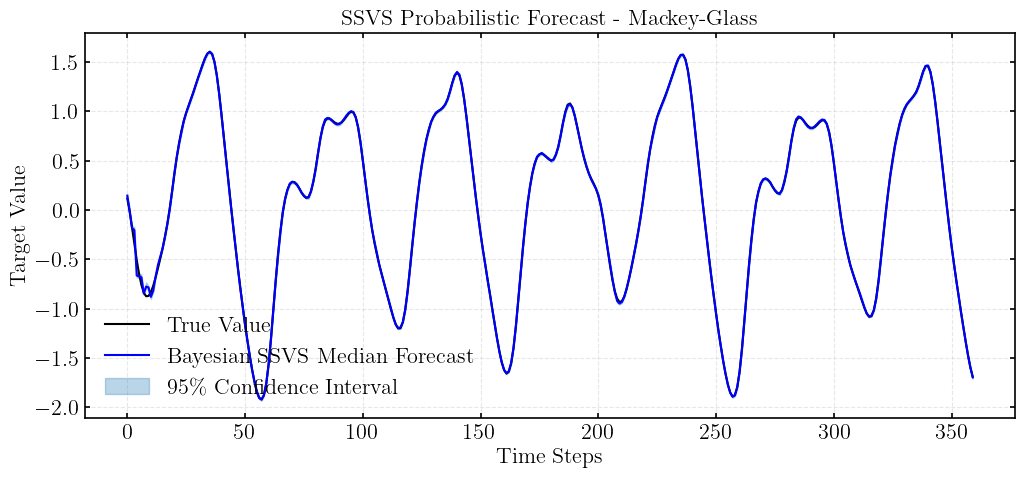

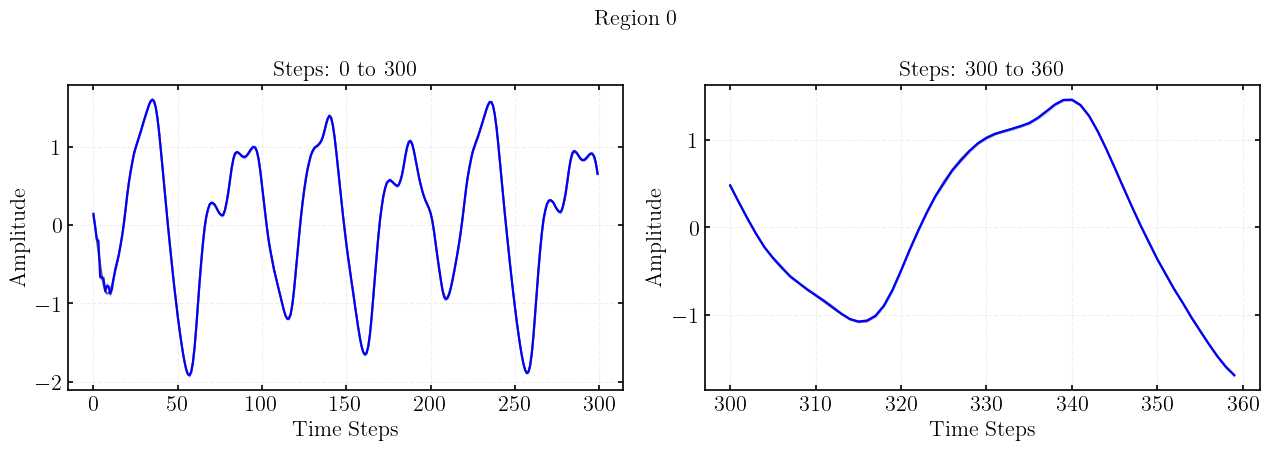

In [7]:
# Evaluate the model
ssvs_mg_model.evaluate_and_plot(Xtest_mg_t, Ytest_mg_t, target_name="Mackey-Glass")

In [8]:
ssvs_mg_metrics = ssvs_mg_model.compute_metrics(Xtest_mg_t, Ytest_mg_t)

# Save the metrics
ssvs_mg_mse = ssvs_mg_metrics[0]
ssvs_mg_coverage = ssvs_mg_metrics[1]
ssvs_mg_width = ssvs_mg_metrics[2]
ssvs_mg_cal_error = ssvs_mg_metrics[3]
ssvs_mg_mcrps = ssvs_mg_metrics[4]

FINAL METRICS:
MSE: 0.0002
Coverage: 91.11%
Mean Width: 0.0242
Calibration Error: 0.0019
mCRPS: 0.0037


# fMRI dataset analysis

In [9]:
train_mat = sio.loadmat("100307.REST1.LR.SchaeferS.ptseries.mat")
test_mat = sio.loadmat("100307.REST2.LR.SchaeferS.ptseries.mat")

train_data = train_mat["tseries"].T
test_data = test_mat["tseries"].T

scaler_train = StandardScaler()
scaler_test = StandardScaler() 
train_scaled = scaler_train.fit_transform(train_data)
test_scaled = scaler_test.fit_transform(test_data)

target_reg = 0
X_tr_fmri = train_scaled[:-1, :]
Y_tr_fmri = train_scaled[1:, target_reg].reshape(-1, 1)

X_ts_fmri = test_scaled[:-1, :]
Y_ts_fmri = test_scaled[1:, target_reg].reshape(-1, 1)

X_tr_numpy = X_tr_fmri
Y_tr_numpy = Y_tr_fmri
X_ts_numpy = X_ts_fmri
Y_ts_numpy = Y_ts_fmri

In [10]:
print("\nMCMC GRID SEARCH ON fMRI DATASET")
param_grid = {
    "num_samples": [1000],           
    "warmup_steps": [500],            
    "spectral_radius": [0.9]    
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Starting grid search on {len(combinations)} combinations...")

best_mse = float("inf")
best_params = None
ssvs_fmri_model = None  

for idx, config in enumerate(combinations):
    print(f"\n[{idx+1}/{len(combinations)}] Test Config: {config}")
    
    n_samp = config["num_samples"]
    w_steps = config["warmup_steps"]
    sr = config["spectral_radius"]
    
    try:
        # Create reservoir
        res_grid = Reservoir(input_dim=X_tr_numpy.shape[1], reservoir_dim=500, spectral_radius=sr, seed=42)
        S_train_raw = res_grid.get_states(X_tr_numpy)
        S_test_raw = res_grid.get_states(X_ts_numpy)
        
        X_tr_t = torch.tensor(S_train_raw, dtype=torch.float32)
        Y_tr_t = torch.tensor(Y_tr_numpy, dtype=torch.float32)
        X_ts_t = torch.tensor(S_test_raw, dtype=torch.float32)
        
        # Instantiate the object and fit the model
        ssvs_model = SSVS(num_samples=n_samp, warmup_steps=w_steps)
        ssvs_model.fit(X_tr_t, Y_tr_t)
        
        # Evaluate
        samples = ssvs_model.predict(X_ts_t)
        y_pred_mean = torch.median(samples["obs"], dim=0).values.detach().numpy()
        current_mse = mean_squared_error(Y_ts_numpy.flatten(), y_pred_mean.flatten())
        
        print(f"Test MSE: {current_mse:.4f}")
        
        if current_mse < best_mse:
            best_mse = current_mse
            best_params = config
            ssvs_fmri_model = ssvs_model 
            print(f"New best model found!")
            
    except Exception as e:
        print(f"Error with this configuration: {e}")

print(f"GRID SEARCH COMPLETED!")
print(f"Best parameters: {best_params}")
print(f"Best MSE: {best_mse:.4f}")


MCMC GRID SEARCH ON fMRI DATASET
Starting grid search on 1 combinations...

[1/1] Test Config: {'num_samples': 1000, 'warmup_steps': 500, 'spectral_radius': 0.9}
MCMC training (Samples: 1000, Warmup: 500)...


Sample: 100%|██████████| 1500/1500 [27:35,  1.10s/it, step size=2.29e-03, acc. prob=0.700]


Test MSE: 0.7323
New best model found!
GRID SEARCH COMPLETED!
Best parameters: {'num_samples': 1000, 'warmup_steps': 500, 'spectral_radius': 0.9}
Best MSE: 0.7323


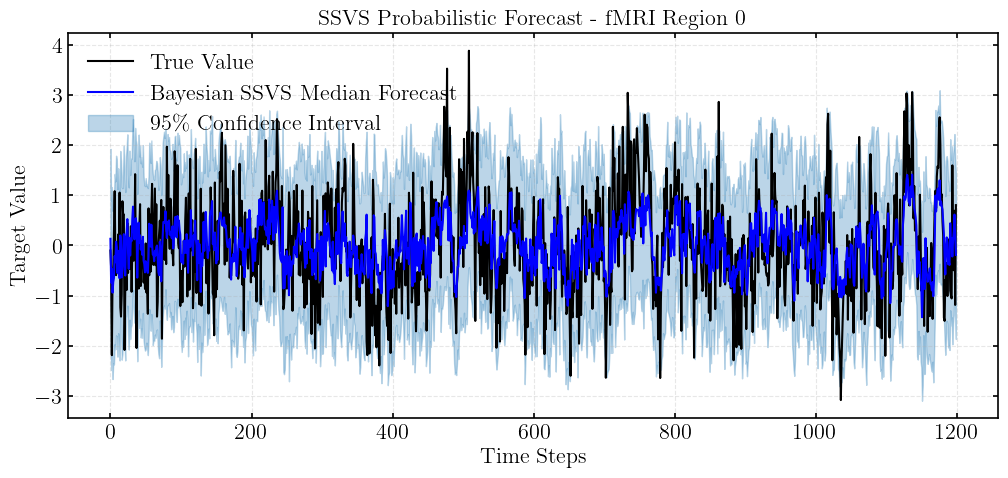

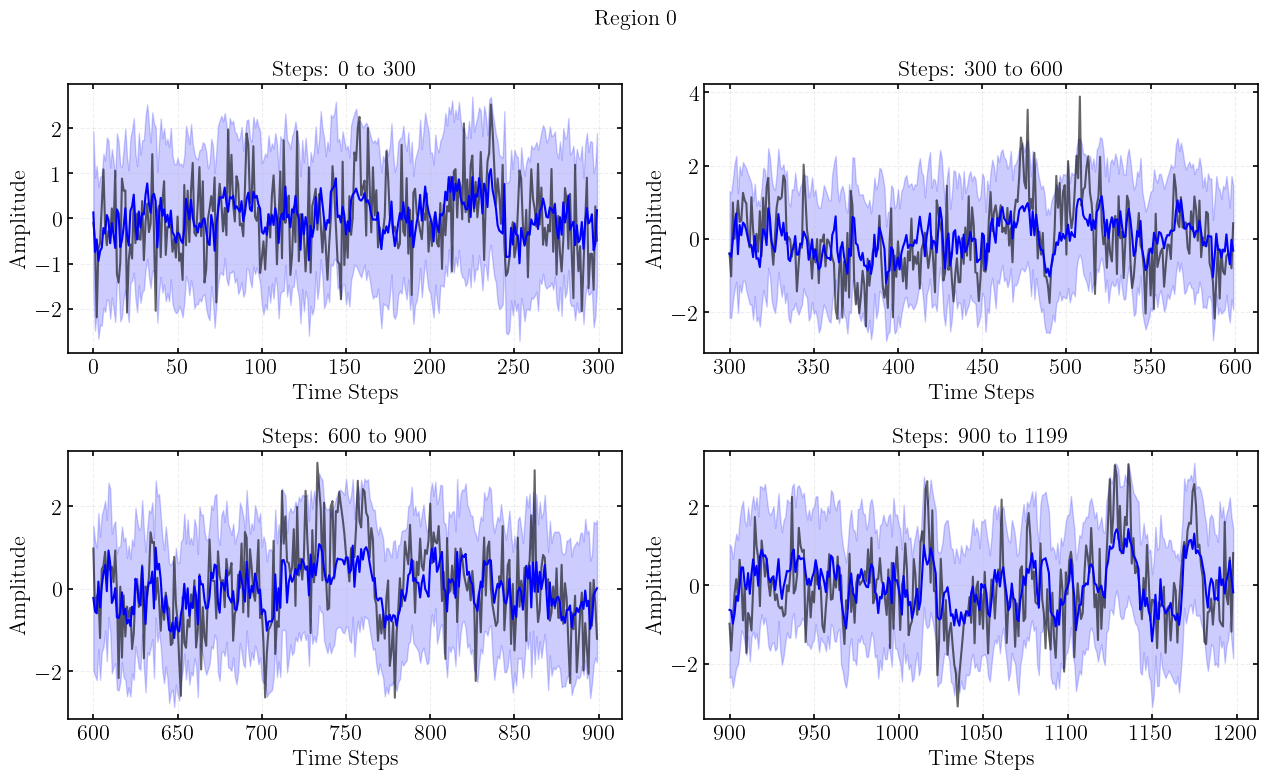

In [11]:
# Evaluate the best model
best_res = Reservoir(input_dim=X_tr_numpy.shape[1], reservoir_dim=500, spectral_radius=best_params["spectral_radius"], seed=42)
S_test_best = best_res.get_states(X_ts_numpy)

X_test_best_t = torch.tensor(S_test_best, dtype=torch.float32)
Y_test_t = torch.tensor(Y_ts_numpy, dtype=torch.float32)

ssvs_fmri_model.evaluate_and_plot(X_test_best_t, Y_test_t, target_name=f"fMRI Region {target_reg}")

In [12]:
ssvs_fmri_metrics = ssvs_fmri_model.compute_metrics(Xtest_mg_t, Ytest_mg_t)

# Save the metrics
ssvs_fmri_mse = ssvs_fmri_metrics[0]
ssvs_fmri_coverage = ssvs_fmri_metrics[1]
ssvs_fmri_width = ssvs_fmri_metrics[2]
ssvs_fmri_cal_error = ssvs_fmri_metrics[3]
ssvs_fmri_mcrps = ssvs_fmri_metrics[4]

FINAL METRICS:
MSE: 0.6595
Coverage: 99.17%
Mean Width: 3.2449
Calibration Error: 0.0083
mCRPS: 0.2863


In [13]:
num_regions_to_test = train_scaled.shape[1]  

X_train = train_scaled[:-1, :]
Y_train = train_scaled[1:, :num_regions_to_test] 

X_test = test_scaled[:-1, :]
Y_test = test_scaled[1:, :num_regions_to_test]

print(f"Number of target regions for MCMC: {num_regions_to_test}")

# Initialize Reservoir
res = Reservoir(input_dim=X_train.shape[1], 
                reservoir_dim=500, 
                spectral_radius=0.5, 
                seed=42)

S_train = res.get_states(X_train)
S_test  = res.get_states(X_test)

Xtrain_tensor = torch.tensor(S_train, dtype=torch.float32)
Ytrain_tensor = torch.tensor(Y_train, dtype=torch.float32)
Xtest_tensor = torch.tensor(S_test, dtype=torch.float32)
Ytest_tensor = torch.tensor(Y_test, dtype=torch.float32)


def ssvs_model_multi(X, Y=None, num_regions=1):
    N_features = X.shape[1]
    
    # Parameters definition
    tau = pyro.sample("tau", dist.HalfCauchy(torch.ones(num_regions)))
    bias = pyro.sample("bias", dist.Normal(torch.zeros(num_regions), torch.full((num_regions,), 10.0)))
    sigma = pyro.sample("sigma", dist.Uniform(torch.zeros(num_regions), torch.full((num_regions,), 10.0)))
    
    # Sampling of Beta
    with pyro.plate("features_plate", N_features, dim=-2):
        lambdas = pyro.sample("lambdas", dist.HalfCauchy(torch.ones(num_regions)))
        beta = pyro.sample("beta", dist.Normal(torch.zeros(num_regions), lambdas * tau))
        
    mu = torch.matmul(X, beta) + bias  
    
    with pyro.plate("data_plate", X.shape[0], dim=-1):
        pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=Y)


# Training
pyro.clear_param_store()

num_samples = 200 
warmup_steps = 50

nuts_kernel = NUTS(ssvs_model_multi)
mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup_steps)

print(f"\nTraining of MCMC (Samples: {num_samples}, Warmup: {warmup_steps})...")
mcmc.run(Xtrain_tensor, Ytrain_tensor, num_regions=num_regions_to_test)

# Extract results and make predictions
posterior_samples = mcmc.get_samples()
predictive = Predictive(ssvs_model_multi, posterior_samples=posterior_samples, return_sites=("obs",))

samples = predictive(Xtest_tensor, Y=None, num_regions=num_regions_to_test)
y_pred_samples = samples["obs"]

y_pred_mean = torch.median(y_pred_samples, dim=0).values.detach().numpy()
y_true = Ytest_tensor.numpy()

y_true_scaled = y_true.T
y_mean_scaled = y_pred_mean.T

Number of target regions for MCMC: 119

Training of MCMC (Samples: 200, Warmup: 50)...


Sample: 100%|██████████| 250/250 [13:13,  3.17s/it, step size=3.74e-04, acc. prob=0.274]


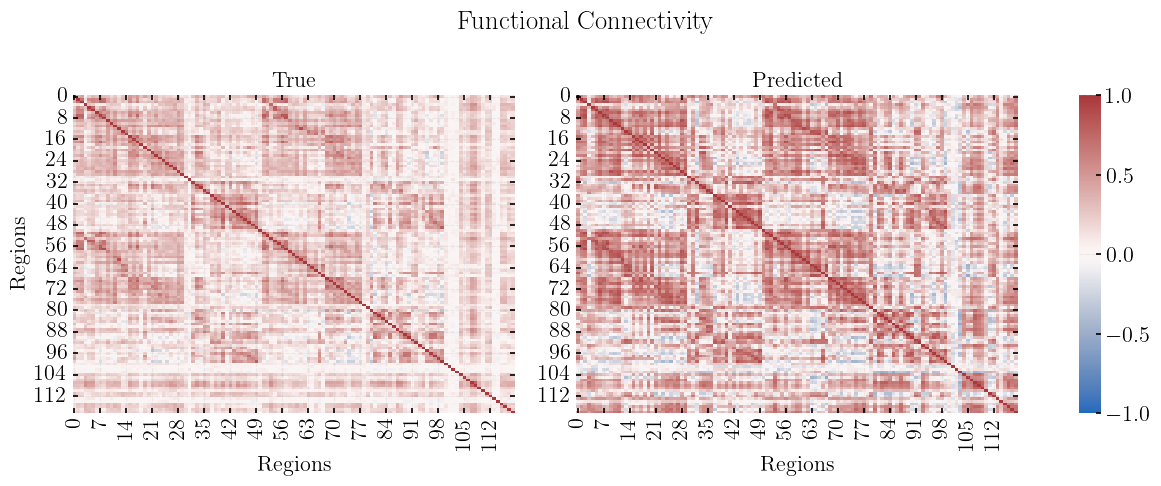

In [14]:
import seaborn as sns
# Plot heatmaps
posterior_samples = mcmc.get_samples()
predictive = Predictive(ssvs_model_multi, posterior_samples=posterior_samples, return_sites=("obs",))

samples = predictive(Xtest_tensor, Y=None, num_regions=num_regions_to_test)
y_pred_samples = samples["obs"]

y_pred_mean = torch.median(y_pred_samples, dim=0).values.squeeze().detach().numpy()
y_true = Ytest_tensor.numpy()

y_true_scaled = y_true.T
y_mean_scaled = y_pred_mean.T


fig, ax = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle(f"Functional Connectivity")

# True
corr_true = np.corrcoef(y_true_scaled)  
sns.heatmap(corr_true, vmin=-1, vmax=1, cmap='vlag', ax=ax[0], cbar=False)
ax[0].set_title("True")
ax[0].set_xlabel("Regions")
ax[0].set_ylabel("Regions")

# Predicted
corr_pred = np.corrcoef(y_mean_scaled)  
sns.heatmap(corr_pred, vmin=-1, vmax=1, cmap='vlag', ax=ax[1], cbar=True, cbar_ax=ax[2])
ax[1].set_title("Predicted")
ax[1].set_xlabel("Regions")

plt.tight_layout()
plt.show()